# Position Analysis HDF5 Overview

This notebook is the starting point for exploring the canonical `contact_analysis.h5` files for the 2026-04-30 U251 live spinning-disk experiment. It autodiscovers files from the analysis root, reads their HDF5 tables, builds a compact catalog, and writes a project description summarizing what is available.

Only files matching `pos*/4_contact_analysis/contact_analysis.h5` are included. Intermediate HDF5 caches such as graphcut unary caches are intentionally ignored.

## Biological Interpretation

At a high level, these files describe how a mixed U251 glioblastoma cell population moves, packs, contacts neighboring cells, and rearranges over time in confined circular 300 um regions. Each HDF5 file corresponds to one microscope position in the live-imaging experiment.

The files do not store raw image pixels. They store downstream quantitative measurements derived from segmented and tracked cell and nucleus label images. The `cells/table` rows represent tracked cells at individual movie frames, including position, area, perimeter, bounding box, class/status, and nuclear marker summaries. The `edges/table` rows represent cell-cell contacts or adjacencies, so the tissue can be analyzed as a changing neighbor graph. The `t1_events/table` rows capture T1 transitions: local neighbor-exchange events where one cell-cell contact is lost and another is gained.

Biologically, this makes the dataset useful for studying cell density, cell shape, radial organization, contact network structure, and tissue fluidity in the WT-NLS-mCherry and VimentinKO U251 populations. Any biological interpretation should still be checked against segmentation quality and the exact meaning of `class_label` and `nls_status` before comparing cell populations.

In [1]:
from __future__ import annotations

from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import tifffile

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)

ROOT = Path("/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis")
NOTEBOOK_DIR = Path("notebooks") if Path("notebooks/position_analysis_h5_overview.ipynb").exists() else Path(".")
PROJECT_DESCRIPTION_PATH = NOTEBOOK_DIR / "position_analysis_project_description.md"

def discover_position_artifacts(root: Path = ROOT) -> list[Path]:
    """Return canonical per-position analysis artifacts, sorted by position name."""
    return sorted(root.glob("pos*/4_contact_analysis/contact_analysis.h5"))

artifact_paths = discover_position_artifacts()
print(f"Discovered {len(artifact_paths)} contact_analysis.h5 files under {ROOT}")
for path in artifact_paths:
    print(path.relative_to(ROOT))

Discovered 9 contact_analysis.h5 files under /home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis
pos00/4_contact_analysis/contact_analysis.h5
pos01/4_contact_analysis/contact_analysis.h5
pos02/4_contact_analysis/contact_analysis.h5
pos03/4_contact_analysis/contact_analysis.h5
pos04/4_contact_analysis/contact_analysis.h5
pos05/4_contact_analysis/contact_analysis.h5
pos06/4_contact_analysis/contact_analysis.h5
pos07/4_contact_analysis/contact_analysis.h5
pos08/4_contact_analysis/contact_analysis.h5


## Reader Helpers

The CellFlow artifact uses HDF5 groups as column tables. The helpers below convert those groups into pandas DataFrames and carry the position label (`pos00`, `pos01`, ...) on every row so pooled analysis can group or filter by position.

In [2]:
def read_dataset(dataset: h5py.Dataset) -> np.ndarray:
    """Read a dataset, decoding HDF5 strings to Python strings."""
    if h5py.check_string_dtype(dataset.dtype) is not None:
        return dataset.asstr()[:]
    return dataset[:]


def read_table(group: h5py.Group) -> pd.DataFrame:
    """Read a CellFlow column-table HDF5 group into a DataFrame."""
    columns = {name: read_dataset(dataset) for name, dataset in group.items()}
    return pd.DataFrame(columns)


def group_inventory(h5: h5py.File) -> pd.DataFrame:
    """Return one row per dataset with path, shape, and dtype."""
    rows = []

    def visit(name: str, obj) -> None:
        if isinstance(obj, h5py.Dataset):
            rows.append({"dataset": name, "shape": obj.shape, "dtype": str(obj.dtype)})

    h5.visititems(visit)
    return pd.DataFrame(rows)


def read_artifact(path: Path, root: Path = ROOT) -> dict[str, object]:
    """Read one contact_analysis.h5 artifact into tables and metadata."""
    position = path.parents[1].name
    with h5py.File(path, "r") as h5:
        cells = read_table(h5["cells/table"])
        edges = read_table(h5["edges/table"])
        t1_events = read_table(h5["t1_events/table"])
        provenance = {key: h5["provenance"].attrs[key] for key in h5["provenance"].attrs.keys()}
        inventory = group_inventory(h5)

    for table in (cells, edges, t1_events):
        table.insert(0, "position", position)

    return {
        "path": path,
        "relative_path": path.relative_to(root),
        "position": position,
        "cells": cells,
        "edges": edges,
        "t1_events": t1_events,
        "provenance": provenance,
        "inventory": inventory,
    }


artifacts = [read_artifact(path) for path in artifact_paths]
len(artifacts)

9

## Catalog and Pooled Tables

The `catalog` table has one row per HDF5 file. The `cells`, `edges`, and `t1_events` tables concatenate all discovered positions for downstream number crunching.

In [3]:
catalog_rows = []
for item in artifacts:
    cells_i = item["cells"]
    edges_i = item["edges"]
    t1_i = item["t1_events"]
    frames = sorted(cells_i["frame"].unique().tolist()) if "frame" in cells_i else []
    catalog_rows.append(
        {
            "position": item["position"],
            "path": str(item["relative_path"]),
            "n_cell_rows": len(cells_i),
            "n_unique_cell_ids": cells_i["cell_id"].nunique() if "cell_id" in cells_i else np.nan,
            "n_edge_rows": len(edges_i),
            "n_unique_edge_ids": edges_i["edge_id"].nunique() if "edge_id" in edges_i else np.nan,
            "n_t1_events": len(t1_i),
            "first_frame": min(frames) if frames else np.nan,
            "last_frame": max(frames) if frames else np.nan,
            "n_frames_with_cells": len(frames),
            "created_at": item["provenance"].get("created_at", ""),
            "cellflow_version": item["provenance"].get("cellflow_version", ""),
        }
    )

catalog = pd.DataFrame(catalog_rows).sort_values("position").reset_index(drop=True)
cells = pd.concat([item["cells"] for item in artifacts], ignore_index=True) if artifacts else pd.DataFrame()
edges = pd.concat([item["edges"] for item in artifacts], ignore_index=True) if artifacts else pd.DataFrame()
t1_events = pd.concat([item["t1_events"] for item in artifacts], ignore_index=True) if artifacts else pd.DataFrame()

catalog

,position,path,n_cell_rows,n_unique_cell_ids,n_edge_rows,n_unique_edge_ids,n_t1_events,first_frame,last_frame,n_frames_with_cells,created_at,cellflow_version
0,pos00,pos00/4_contact_analysis/contact_analysis.h5,2762,60,23152,312,112,0,47,48,2026-05-12T23:34:43.930081+00:00,0.2.0
1,pos01,pos01/4_contact_analysis/contact_analysis.h5,1559,34,12323,158,14,0,49,50,2026-05-10T08:09:29.194022+00:00,0.2.0
2,pos02,pos02/4_contact_analysis/contact_analysis.h5,2014,48,15515,236,46,0,43,44,2026-05-12T23:31:00.515592+00:00,0.2.0
3,pos03,pos03/4_contact_analysis/contact_analysis.h5,1497,31,11319,146,19,0,49,50,2026-05-12T23:33:15.695974+00:00,0.2.0
4,pos04,pos04/4_contact_analysis/contact_analysis.h5,3091,64,19065,385,184,0,49,50,2026-05-12T19:15:34.361170+00:00,0.2.0
5,pos05,pos05/4_contact_analysis/contact_analysis.h5,2330,49,20444,250,49,0,49,50,2026-05-16T13:39:50.474518+00:00,0.2.0
6,pos06,pos06/4_contact_analysis/contact_analysis.h5,1210,25,9415,104,2,0,49,50,2026-05-13T22:42:35.015018+00:00,0.2.0
7,pos07,pos07/4_contact_analysis/contact_analysis.h5,2677,55,24447,317,132,0,49,50,2026-05-14T01:25:50.419304+00:00,0.2.0
8,pos08,pos08/4_contact_analysis/contact_analysis.h5,3144,66,27758,469,222,0,49,50,2026-05-16T15:26:38.403716+00:00,0.2.0


In [4]:
print("Pooled table shapes")
print(f"cells:     {cells.shape}")
print(f"edges:     {edges.shape}")
print(f"t1_events: {t1_events.shape}")

display(cells.head())
display(edges.head())
display(t1_events.head())

Pooled table shapes
cells:     (20284, 16)
edges:     (163438, 14)
t1_events: (780, 10)


,position,frame,cell_id,area,centroid_y,centroid_x,perimeter,bbox_min_y,bbox_min_x,bbox_max_y,bbox_max_x,class_label,nls_status,nls_track_median_intensity,nls_track_pixel_count,nls_track_frame_count
0,pos00,0,1,4426.0,75.936737,346.304338,327.155375,32,285,116,399,vimentin_ko,low,107.0,32462,48
1,pos00,0,2,1697.0,75.147908,148.365351,206.929978,44,123,116,175,vimentin_ko,low,106.0,16408,48
2,pos00,0,3,3172.0,106.177491,290.428121,238.936075,79,246,145,329,vimentin_ko,low,106.0,24472,48
3,pos00,0,4,2194.0,107.513674,100.912489,226.492424,68,70,152,131,vimentin_ko,low,106.0,16775,48
4,pos00,0,5,3167.0,132.402589,417.971898,271.492424,99,374,170,460,ctrl,high,161.0,19774,48


,position,frame,edge_id,cell_a,cell_b,kind,edge_label,is_t1_frame,t1_event_id,length,midpoint_y,midpoint_x,coord_offset,coord_count
0,pos00,0,1,1,3,cell_cell,,False,-1,22.435029,92.5,323.0,0,29
1,pos00,0,2,1,5,cell_cell,,False,-1,29.970563,108.5,385.0,29,38
2,pos00,0,3,1,58,cell_cell,,False,-1,27.263456,48.5,298.0,67,35
3,pos00,0,4,2,4,cell_cell,,False,-1,31.142136,80.5,129.0,102,38
4,pos00,0,5,2,45,cell_cell,,False,-1,24.071068,105.0,131.5,140,28


,position,t1_event_id,frame,edge_id,losing_cell_a,losing_cell_b,gaining_cell_a,gaining_cell_b,location_y,location_x
0,pos00,1,0,63,19,48,11,49,210.0,388.5
1,pos00,2,0,120,54,58,52,56,73.5,224.0
2,pos00,3,1,63,11,49,19,48,211.5,387.0
3,pos00,4,1,78,26,42,24,40,320.5,98.0
4,pos00,5,1,88,29,38,27,32,369.5,145.0


## Population Identity and Marker QC

Before comparing WT-NLS-mCherry and VimentinKO behavior, check what the identity/status columns contain and whether the nuclear marker intensity separates into interpretable groups.

In [5]:
marker_columns = [
    "position",
    "frame",
    "cell_id",
    "class_label",
    "nls_status",
    "nls_track_median_intensity",
    "nls_track_pixel_count",
    "nls_track_frame_count",
]
marker_columns = [column for column in marker_columns if column in cells.columns]

population_preview = cells[marker_columns].sort_values(["position", "frame", "cell_id"]).head(20)
population_preview

,position,frame,cell_id,class_label,nls_status,nls_track_median_intensity,nls_track_pixel_count,nls_track_frame_count
0,pos00,0,1,vimentin_ko,low,107.0,32462,48
1,pos00,0,2,vimentin_ko,low,106.0,16408,48
2,pos00,0,3,vimentin_ko,low,106.0,24472,48
3,pos00,0,4,vimentin_ko,low,106.0,16775,48
4,pos00,0,5,ctrl,high,161.0,19774,48
5,pos00,0,6,ctrl,high,262.0,34432,48
6,pos00,0,7,ctrl,high,223.0,35183,48
7,pos00,0,8,ctrl,high,164.0,14847,48
8,pos00,0,9,vimentin_ko,low,106.0,12947,48
9,pos00,0,10,vimentin_ko,low,106.0,32630,48


In [6]:
identity_columns = [column for column in ["class_label", "nls_status"] if column in cells.columns]

population_counts = (
    cells.groupby(identity_columns, dropna=False)
    .agg(
        n_rows=("cell_id", "size"),
        n_cell_tracks=("cell_id", "nunique"),
        n_positions=("position", "nunique"),
        first_frame=("frame", "min"),
        last_frame=("frame", "max"),
    )
    .reset_index()
    .sort_values("n_rows", ascending=False)
    if identity_columns else pd.DataFrame()
)

population_counts

,class_label,nls_status,n_rows,n_cell_tracks,n_positions,first_frame,last_frame
1,vimentin_ko,low,12840,81,9,0,49
0,ctrl,high,7444,73,9,0,49


In [7]:
marker_intensity_summary = cells["nls_track_median_intensity"].describe() if "nls_track_median_intensity" in cells.columns else pd.Series(dtype=float)

marker_by_identity = (
    cells.groupby(identity_columns, dropna=False)["nls_track_median_intensity"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .reset_index()
    .sort_values("median", ascending=False)
    if identity_columns and "nls_track_median_intensity" in cells.columns else pd.DataFrame()
)

display(marker_intensity_summary)
display(marker_by_identity)

count    20284.000000
mean       126.586472
std         32.782081
min        104.000000
25%        108.000000
50%        112.000000
75%        134.000000
max        360.000000
Name: nls_track_median_intensity, dtype: float64

,class_label,nls_status,count,mean,std,min,median,max
0,ctrl,high,7444,156.263702,39.036934,116.0,146.0,360.0
1,vimentin_ko,low,12840,109.381075,2.762624,104.0,110.0,116.0


## Population Composition Over Time

These summaries ask whether positions have comparable mixtures of `ctrl` and `vimentin_ko` cells, and whether the population fractions drift over the movie.

In [8]:
population_by_position = (
    cells.groupby(["position", "class_label"], dropna=False, as_index=False)
    .agg(
        n_rows=("cell_id", "size"),
        n_tracks=("cell_id", "nunique"),
        first_frame=("frame", "min"),
        last_frame=("frame", "max"),
        median_marker=("nls_track_median_intensity", "median"),
        median_area=("area", "median"),
    )
    .sort_values(["position", "class_label"])
)

population_by_position

,position,class_label,n_rows,n_tracks,first_frame,last_frame,median_marker,median_area
0,pos00,ctrl,895,21,0,47,150.0,1870.0
1,pos00,vimentin_ko,1867,39,0,47,106.0,1833.0
2,pos01,ctrl,538,11,0,49,149.0,1971.0
3,pos01,vimentin_ko,1021,23,0,49,111.0,2584.0
4,pos02,ctrl,716,17,0,43,138.0,2681.5
5,pos02,vimentin_ko,1298,31,0,43,107.0,2074.5
6,pos03,ctrl,574,12,0,49,172.0,2039.0
7,pos03,vimentin_ko,923,19,0,49,106.0,3447.0
8,pos04,ctrl,1110,23,0,49,146.0,1749.5
9,pos04,vimentin_ko,1981,41,0,49,112.0,2037.0


In [9]:
population_by_frame = (
    cells.groupby(["position", "frame", "class_label"], dropna=False, as_index=False)
    .agg(
        n_cells=("cell_id", "nunique"),
        median_marker=("nls_track_median_intensity", "median"),
        median_area=("area", "median"),
    )
    .sort_values(["position", "frame", "class_label"])
)

frame_totals = (
    population_by_frame.groupby(["position", "frame"], as_index=False)["n_cells"]
    .sum()
    .rename(columns={"n_cells": "total_cells"})
)

population_fraction_by_frame = population_by_frame.merge(frame_totals, on=["position", "frame"], how="left")
population_fraction_by_frame["fraction_of_frame"] = population_fraction_by_frame["n_cells"] / population_fraction_by_frame["total_cells"]

population_fraction_by_frame.head(20)

,position,frame,class_label,n_cells,median_marker,median_area,total_cells,fraction_of_frame
0,pos00,0,ctrl,19,150.0,2066.0,56,0.339286
1,pos00,0,vimentin_ko,37,106.0,1702.0,56,0.660714
2,pos00,1,ctrl,19,150.0,1985.0,56,0.339286
3,pos00,1,vimentin_ko,37,106.0,1926.0,56,0.660714
4,pos00,2,ctrl,19,150.0,2180.0,57,0.333333
5,pos00,2,vimentin_ko,38,106.0,1764.0,57,0.666667
6,pos00,3,ctrl,19,150.0,2213.0,58,0.327586
7,pos00,3,vimentin_ko,39,106.0,1682.0,58,0.672414
8,pos00,4,ctrl,19,150.0,2128.0,58,0.327586
9,pos00,4,vimentin_ko,39,106.0,1752.0,58,0.672414


In [10]:
population_fraction_summary = (
    population_fraction_by_frame.groupby(["position", "class_label"], dropna=False, as_index=False)
    .agg(
        mean_fraction=("fraction_of_frame", "mean"),
        min_fraction=("fraction_of_frame", "min"),
        max_fraction=("fraction_of_frame", "max"),
        mean_cells_per_frame=("n_cells", "mean"),
        min_cells_per_frame=("n_cells", "min"),
        max_cells_per_frame=("n_cells", "max"),
    )
    .sort_values(["position", "class_label"])
)

population_fraction_summary

,position,class_label,mean_fraction,min_fraction,max_fraction,mean_cells_per_frame,min_cells_per_frame,max_cells_per_frame
0,pos00,ctrl,0.323938,0.303571,0.339286,18.645833,17,20
1,pos00,vimentin_ko,0.676062,0.660714,0.696429,38.895833,37,39
2,pos01,ctrl,0.345034,0.322581,0.354839,10.760000,10,11
3,pos01,vimentin_ko,0.654966,0.645161,0.677419,20.420000,20,21
4,pos02,ctrl,0.355507,0.347826,0.363636,16.272727,16,17
5,pos02,vimentin_ko,0.644493,0.636364,0.652174,29.500000,28,30
6,pos03,ctrl,0.383306,0.379310,0.400000,11.480000,11,12
7,pos03,vimentin_ko,0.616694,0.600000,0.620690,18.460000,18,19
8,pos04,ctrl,0.359228,0.349206,0.372881,22.200000,21,23
9,pos04,vimentin_ko,0.640772,0.627119,0.650794,39.620000,37,41


## Cell Morphology By Population

These summaries compare basic cell morphology between `ctrl` and `vimentin_ko`: area, perimeter, and a simple shape index defined as `perimeter / sqrt(area)`. The position-level table is the safer first read because it shows whether the pooled difference is consistent across fields of view.

In [11]:
cells["shape_index"] = cells["perimeter"] / np.sqrt(cells["area"])

morphology_by_population = (
    cells.groupby("class_label", dropna=False, as_index=False)
    .agg(
        n_rows=("cell_id", "size"),
        n_tracks=("cell_id", "nunique"),
        median_area=("area", "median"),
        mean_area=("area", "mean"),
        median_perimeter=("perimeter", "median"),
        mean_perimeter=("perimeter", "mean"),
        median_shape_index=("shape_index", "median"),
        mean_shape_index=("shape_index", "mean"),
    )
    .sort_values("class_label")
)

morphology_by_population

,class_label,n_rows,n_tracks,median_area,mean_area,median_perimeter,mean_perimeter,median_shape_index,mean_shape_index
0,ctrl,7444,73,2086.5,2503.589871,224.994949,237.079379,4.862782,4.945747
1,vimentin_ko,12840,81,2288.0,2670.404439,236.699008,246.620876,4.840472,4.951165


In [12]:
morphology_by_position = (
    cells.groupby(["position", "class_label"], dropna=False, as_index=False)
    .agg(
        n_rows=("cell_id", "size"),
        n_tracks=("cell_id", "nunique"),
        median_area=("area", "median"),
        mean_area=("area", "mean"),
        median_perimeter=("perimeter", "median"),
        mean_perimeter=("perimeter", "mean"),
        median_shape_index=("shape_index", "median"),
        mean_shape_index=("shape_index", "mean"),
    )
    .sort_values(["position", "class_label"])
)

morphology_by_position

,position,class_label,n_rows,n_tracks,median_area,mean_area,median_perimeter,mean_perimeter,median_shape_index,mean_shape_index
0,pos00,ctrl,895,21,1870.0,2995.202235,209.929978,234.933821,4.769655,4.810884
1,pos00,vimentin_ko,1867,39,1833.0,2048.203535,215.965512,216.751725,4.850269,4.934062
2,pos01,ctrl,538,11,1971.0,2271.801115,221.234542,229.892621,4.967582,5.015319
3,pos01,vimentin_ko,1021,23,2584.0,3335.056807,257.279221,266.575410,4.871109,4.967589
4,pos02,ctrl,716,17,2681.5,2780.797486,265.178716,267.683156,5.114641,5.154672
5,pos02,vimentin_ko,1298,31,2074.5,2487.847458,218.559921,234.444432,4.734776,4.872599
6,pos03,ctrl,574,12,2039.0,2187.108014,221.163474,229.096672,4.935600,5.005776
7,pos03,vimentin_ko,923,19,3447.0,3633.536295,297.877200,296.258788,4.855703,5.020844
8,pos04,ctrl,1110,23,1749.5,2244.857658,193.773124,213.052158,4.612256,4.720486
9,pos04,vimentin_ko,1981,41,2037.0,2409.174659,217.480231,232.785919,4.778832,4.885838


## Cell-Cell Contact Composition

Annotate each cell-cell edge with the population identity of both neighboring cells. This lets us ask whether contacts are mostly `ctrl-ctrl`, `ctrl-vimentin_ko`, or `vimentin_ko-vimentin_ko`, and whether contact length differs by pair type.

In [13]:
cell_identity = cells[["position", "frame", "cell_id", "class_label", "nls_status"]].drop_duplicates(
    ["position", "frame", "cell_id"]
)
cell_cell_edges = edges[edges["kind"].eq("cell_cell")].copy()

edge_kind_summary = (
    edges.groupby("kind", dropna=False, as_index=False)
    .agg(n_edges=("edge_id", "size"), median_length=("length", "median"), mean_length=("length", "mean"))
    .sort_values("n_edges", ascending=False)
)

edge_classes = (
    cell_cell_edges.merge(
        cell_identity.rename(columns={"cell_id": "cell_a", "class_label": "class_a", "nls_status": "nls_status_a"}),
        on=["position", "frame", "cell_a"],
        how="left",
    )
    .merge(
        cell_identity.rename(columns={"cell_id": "cell_b", "class_label": "class_b", "nls_status": "nls_status_b"}),
        on=["position", "frame", "cell_b"],
        how="left",
    )
)

edge_classes["pair_type"] = edge_classes.apply(
    lambda row: "-".join(sorted([str(row["class_a"]), str(row["class_b"])])),
    axis=1,
)

display(edge_kind_summary)
edge_classes[["position", "frame", "edge_id", "cell_a", "cell_b", "class_a", "class_b", "pair_type", "length"]].head(20)

,kind,n_edges,median_length,mean_length
1,cell_cell,86235,7.949747,16.531172
0,border,77203,6.949747,27.243398


,position,frame,edge_id,cell_a,cell_b,class_a,class_b,pair_type,length
0,pos00,0,1,1,3,vimentin_ko,vimentin_ko,vimentin_ko-vimentin_ko,22.435029
1,pos00,0,2,1,5,vimentin_ko,ctrl,ctrl-vimentin_ko,29.970563
2,pos00,0,3,1,58,vimentin_ko,vimentin_ko,vimentin_ko-vimentin_ko,27.263456
3,pos00,0,4,2,4,vimentin_ko,vimentin_ko,vimentin_ko-vimentin_ko,31.142136
4,pos00,0,5,2,45,vimentin_ko,vimentin_ko,vimentin_ko-vimentin_ko,24.071068
5,pos00,0,6,2,53,vimentin_ko,vimentin_ko,vimentin_ko-vimentin_ko,42.234019
6,pos00,0,7,2,54,vimentin_ko,ctrl,ctrl-vimentin_ko,19.485281
7,pos00,0,8,2,57,vimentin_ko,vimentin_ko,vimentin_ko-vimentin_ko,10.535534
8,pos00,0,8,2,57,vimentin_ko,vimentin_ko,vimentin_ko-vimentin_ko,1.000000
9,pos00,0,8,2,57,vimentin_ko,vimentin_ko,vimentin_ko-vimentin_ko,1.414214


In [14]:
contact_pair_summary = (
    edge_classes.groupby("pair_type", dropna=False, as_index=False)
    .agg(
        n_contacts=("edge_id", "size"),
        n_positions=("position", "nunique"),
        median_length=("length", "median"),
        mean_length=("length", "mean"),
        t1_marked_contacts=("is_t1_frame", "sum"),
    )
    .sort_values("n_contacts", ascending=False)
)
contact_pair_summary["fraction_of_contacts"] = contact_pair_summary["n_contacts"] / contact_pair_summary["n_contacts"].sum()

contact_pair_summary

,pair_type,n_contacts,n_positions,median_length,mean_length,t1_marked_contacts,fraction_of_contacts
1,ctrl-vimentin_ko,37604,9,7.949747,16.288163,473,0.436064
2,vimentin_ko-vimentin_ko,35977,9,7.949747,17.066826,455,0.417197
0,ctrl-ctrl,12654,9,7.656854,15.730391,136,0.146739


In [15]:
contact_pair_by_position = (
    edge_classes.groupby(["position", "pair_type"], dropna=False, as_index=False)
    .agg(
        n_contacts=("edge_id", "size"),
        median_length=("length", "median"),
        mean_length=("length", "mean"),
        t1_marked_contacts=("is_t1_frame", "sum"),
    )
    .sort_values(["position", "pair_type"])
)

position_contact_totals = contact_pair_by_position.groupby("position", as_index=False)["n_contacts"].sum().rename(
    columns={"n_contacts": "position_contacts"}
)
contact_pair_by_position = contact_pair_by_position.merge(position_contact_totals, on="position", how="left")
contact_pair_by_position["fraction_of_position_contacts"] = contact_pair_by_position["n_contacts"] / contact_pair_by_position["position_contacts"]

contact_pair_by_position

,position,pair_type,n_contacts,median_length,mean_length,t1_marked_contacts,position_contacts,fraction_of_position_contacts
0,pos00,ctrl-ctrl,1344,7.121320,16.247427,17,12639,0.106338
1,pos00,ctrl-vimentin_ko,5177,6.828427,15.357040,69,12639,0.409605
2,pos00,vimentin_ko-vimentin_ko,6118,5.949747,14.829544,74,12639,0.484057
3,pos01,ctrl-ctrl,751,15.313708,19.261446,0,3826,0.196289
4,pos01,ctrl-vimentin_ko,1472,13.778175,18.337674,9,3826,0.384736
5,pos01,vimentin_ko-vimentin_ko,1603,14.656854,22.207320,6,3826,0.418975
6,pos02,ctrl-ctrl,885,8.828427,14.422504,3,8515,0.103934
7,pos02,ctrl-vimentin_ko,4030,5.121320,14.414199,17,8515,0.473282
8,pos02,vimentin_ko-vimentin_ko,3600,6.535534,15.297648,26,8515,0.422783
9,pos03,ctrl-ctrl,1001,6.414214,13.923637,14,4837,0.206946


In [16]:
contact_pair_by_frame = (
    edge_classes.groupby(["position", "frame", "pair_type"], dropna=False, as_index=False)
    .agg(
        n_contacts=("edge_id", "size"),
        median_length=("length", "median"),
        mean_length=("length", "mean"),
    )
    .sort_values(["position", "frame", "pair_type"])
)

contact_pair_by_frame.head(20)

,position,frame,pair_type,n_contacts,median_length,mean_length
0,pos00,0,ctrl-ctrl,37,12.656854,17.809935
1,pos00,0,ctrl-vimentin_ko,103,7.535534,17.704310
2,pos00,0,vimentin_ko-vimentin_ko,98,10.535534,16.530076
3,pos00,1,ctrl-ctrl,42,11.303301,15.943439
4,pos00,1,ctrl-vimentin_ko,99,9.535534,18.436335
5,pos00,1,vimentin_ko-vimentin_ko,122,3.828427,13.604308
6,pos00,2,ctrl-ctrl,46,7.328427,14.029135
7,pos00,2,ctrl-vimentin_ko,131,3.707107,13.293658
8,pos00,2,vimentin_ko-vimentin_ko,124,4.828427,13.998389
9,pos00,3,ctrl-ctrl,28,15.217514,21.740050


## Contact Mixing: Observed Versus Expected

Compare observed contact pair fractions to random-mixing expectations from the population fractions in the same position and frame. For two classes with fractions `p_ctrl` and `p_ko`, the random expectation is `p_ctrl ** 2` for `ctrl-ctrl`, `2 * p_ctrl * p_ko` for mixed contacts, and `p_ko ** 2` for `vimentin_ko-vimentin_ko`.

In [17]:
population_fraction_wide = (
    population_fraction_by_frame.pivot_table(
        index=["position", "frame"],
        columns="class_label",
        values="fraction_of_frame",
        fill_value=0,
    )
    .reset_index()
)

for class_label in ["ctrl", "vimentin_ko"]:
    if class_label not in population_fraction_wide.columns:
        population_fraction_wide[class_label] = 0.0

expected_contact_fraction_by_frame = pd.concat(
    [
        population_fraction_wide.assign(
            pair_type="ctrl-ctrl",
            expected_fraction=population_fraction_wide["ctrl"] ** 2,
        )[["position", "frame", "pair_type", "expected_fraction"]],
        population_fraction_wide.assign(
            pair_type="ctrl-vimentin_ko",
            expected_fraction=2 * population_fraction_wide["ctrl"] * population_fraction_wide["vimentin_ko"],
        )[["position", "frame", "pair_type", "expected_fraction"]],
        population_fraction_wide.assign(
            pair_type="vimentin_ko-vimentin_ko",
            expected_fraction=population_fraction_wide["vimentin_ko"] ** 2,
        )[["position", "frame", "pair_type", "expected_fraction"]],
    ],
    ignore_index=True,
)

expected_contact_fraction_by_frame.head()

class_label,position,frame,pair_type,expected_fraction
0,pos00,0,ctrl-ctrl,0.115115
1,pos00,1,ctrl-ctrl,0.115115
2,pos00,2,ctrl-ctrl,0.111111
3,pos00,3,ctrl-ctrl,0.107313
4,pos00,4,ctrl-ctrl,0.107313


In [18]:
contact_totals_by_frame = (
    contact_pair_by_frame.groupby(["position", "frame"], as_index=False)["n_contacts"]
    .sum()
    .rename(columns={"n_contacts": "total_contacts"})
)

observed_contact_fraction_by_frame = contact_pair_by_frame.merge(
    contact_totals_by_frame,
    on=["position", "frame"],
    how="left",
)
observed_contact_fraction_by_frame["observed_fraction"] = (
    observed_contact_fraction_by_frame["n_contacts"] / observed_contact_fraction_by_frame["total_contacts"]
)

contact_mixing_by_frame = observed_contact_fraction_by_frame.merge(
    expected_contact_fraction_by_frame,
    on=["position", "frame", "pair_type"],
    how="left",
)
contact_mixing_by_frame["observed_minus_expected"] = (
    contact_mixing_by_frame["observed_fraction"] - contact_mixing_by_frame["expected_fraction"]
)
contact_mixing_by_frame["observed_over_expected"] = (
    contact_mixing_by_frame["observed_fraction"] / contact_mixing_by_frame["expected_fraction"].replace(0, np.nan)
)

contact_mixing_by_frame.head(20)

,position,frame,pair_type,n_contacts,median_length,mean_length,total_contacts,observed_fraction,expected_fraction,observed_minus_expected,observed_over_expected
0,pos00,0,ctrl-ctrl,37,12.656854,17.809935,238,0.155462,0.115115,0.040347,1.350497
1,pos00,0,ctrl-vimentin_ko,103,7.535534,17.704310,238,0.432773,0.448342,-0.015569,0.965275
2,pos00,0,vimentin_ko-vimentin_ko,98,10.535534,16.530076,238,0.411765,0.436543,-0.024779,0.943239
3,pos00,1,ctrl-ctrl,42,11.303301,15.943439,263,0.159696,0.115115,0.044581,1.387274
4,pos00,1,ctrl-vimentin_ko,99,9.535534,18.436335,263,0.376426,0.448342,-0.071916,0.839596
5,pos00,1,vimentin_ko-vimentin_ko,122,3.828427,13.604308,263,0.463878,0.436543,0.027335,1.062617
6,pos00,2,ctrl-ctrl,46,7.328427,14.029135,301,0.152824,0.111111,0.041713,1.375415
7,pos00,2,ctrl-vimentin_ko,131,3.707107,13.293658,301,0.435216,0.444444,-0.009228,0.979236
8,pos00,2,vimentin_ko-vimentin_ko,124,4.828427,13.998389,301,0.411960,0.444444,-0.032484,0.926910
9,pos00,3,ctrl-ctrl,28,15.217514,21.740050,276,0.101449,0.107313,-0.005863,0.945361


In [19]:
contact_mixing_summary = (
    contact_mixing_by_frame.groupby(["position", "pair_type"], as_index=False)
    .agg(
        mean_observed_fraction=("observed_fraction", "mean"),
        mean_expected_fraction=("expected_fraction", "mean"),
        mean_observed_minus_expected=("observed_minus_expected", "mean"),
        mean_observed_over_expected=("observed_over_expected", "mean"),
        n_frames=("frame", "nunique"),
    )
    .sort_values(["position", "pair_type"])
)

contact_mixing_summary

,position,pair_type,mean_observed_fraction,mean_expected_fraction,mean_observed_minus_expected,mean_observed_over_expected,n_frames
0,pos00,ctrl-ctrl,0.105509,0.105032,0.000477,0.999509,48
1,pos00,ctrl-vimentin_ko,0.409762,0.437811,-0.028049,0.935803,48
2,pos00,vimentin_ko-vimentin_ko,0.484729,0.457157,0.027572,1.059612,48
3,pos01,ctrl-ctrl,0.194651,0.119133,0.075518,1.625335,50
4,pos01,ctrl-vimentin_ko,0.382691,0.451801,-0.069110,0.848124,50
5,pos01,vimentin_ko-vimentin_ko,0.422658,0.429066,-0.006407,0.986077,50
6,pos02,ctrl-ctrl,0.103564,0.126421,-0.022856,0.815514,44
7,pos02,ctrl-vimentin_ko,0.471844,0.458173,0.013671,1.030010,44
8,pos02,vimentin_ko-vimentin_ko,0.424591,0.415406,0.009185,1.021993,44
9,pos03,ctrl-ctrl,0.207114,0.146944,0.060170,1.411633,50


## T1 Rearrangements By Contact Pair Type

These summaries ask whether contact instability differs by population pairing. The rate is normalized by the number of observed cell-cell contacts of each pair type, so mixed contacts are compared to same-type contacts on their own exposure.

In [20]:
t1_contact_rate_by_pair = (
    edge_classes.groupby("pair_type", as_index=False)
    .agg(
        n_contacts=("edge_id", "size"),
        n_t1_contacts=("is_t1_frame", "sum"),
        t1_contact_rate=("is_t1_frame", "mean"),
        median_length=("length", "median"),
        mean_length=("length", "mean"),
    )
    .sort_values("t1_contact_rate", ascending=False)
)

t1_contact_rate_by_pair

,pair_type,n_contacts,n_t1_contacts,t1_contact_rate,median_length,mean_length
2,vimentin_ko-vimentin_ko,35977,455,0.012647,7.949747,17.066826
1,ctrl-vimentin_ko,37604,473,0.012578,7.949747,16.288163
0,ctrl-ctrl,12654,136,0.010748,7.656854,15.730391


In [21]:
t1_contact_rate_by_position = (
    edge_classes.groupby(["position", "pair_type"], as_index=False)
    .agg(
        n_contacts=("edge_id", "size"),
        n_t1_contacts=("is_t1_frame", "sum"),
        t1_contact_rate=("is_t1_frame", "mean"),
        median_length=("length", "median"),
        mean_length=("length", "mean"),
    )
    .sort_values(["position", "pair_type"])
)

t1_contact_rate_by_position

,position,pair_type,n_contacts,n_t1_contacts,t1_contact_rate,median_length,mean_length
0,pos00,ctrl-ctrl,1344,17,0.012649,7.121320,16.247427
1,pos00,ctrl-vimentin_ko,5177,69,0.013328,6.828427,15.357040
2,pos00,vimentin_ko-vimentin_ko,6118,74,0.012095,5.949747,14.829544
3,pos01,ctrl-ctrl,751,0,0.000000,15.313708,19.261446
4,pos01,ctrl-vimentin_ko,1472,9,0.006114,13.778175,18.337674
5,pos01,vimentin_ko-vimentin_ko,1603,6,0.003743,14.656854,22.207320
6,pos02,ctrl-ctrl,885,3,0.003390,8.828427,14.422504
7,pos02,ctrl-vimentin_ko,4030,17,0.004218,5.121320,14.414199
8,pos02,vimentin_ko-vimentin_ko,3600,26,0.007222,6.535534,15.297648
9,pos03,ctrl-ctrl,1001,14,0.013986,6.414214,13.923637


In [22]:
t1_contact_fraction_by_frame = (
    edge_classes.groupby(["position", "frame", "pair_type"], as_index=False)
    .agg(
        n_contacts=("edge_id", "size"),
        n_t1_contacts=("is_t1_frame", "sum"),
    )
    .sort_values(["position", "frame", "pair_type"])
)
t1_contact_fraction_by_frame["t1_contact_rate"] = (
    t1_contact_fraction_by_frame["n_t1_contacts"] / t1_contact_fraction_by_frame["n_contacts"]
)

t1_contact_fraction_by_frame.head(20)

,position,frame,pair_type,n_contacts,n_t1_contacts,t1_contact_rate
0,pos00,0,ctrl-ctrl,37,0,0.000000
1,pos00,0,ctrl-vimentin_ko,103,4,0.038835
2,pos00,0,vimentin_ko-vimentin_ko,98,1,0.010204
3,pos00,1,ctrl-ctrl,42,0,0.000000
4,pos00,1,ctrl-vimentin_ko,99,5,0.050505
5,pos00,1,vimentin_ko-vimentin_ko,122,2,0.016393
6,pos00,2,ctrl-ctrl,46,4,0.086957
7,pos00,2,ctrl-vimentin_ko,131,5,0.038168
8,pos00,2,vimentin_ko-vimentin_ko,124,0,0.000000
9,pos00,3,ctrl-ctrl,28,0,0.000000


## Nucleus-Based Migration Speed

Migration is computed from tracked nucleus centroids, not cell-mask centroids. The `contact_analysis.h5` files store the path to each `2_nucleus/tracked_labels.tif` in provenance, so this section reads those label stacks, extracts nucleus centroids by `cell_id`/track, and computes consecutive-frame centroid displacement in pixels per frame.

In [23]:
def nucleus_centroids_from_labels(labels: np.ndarray) -> pd.DataFrame:
    labels = np.asarray(labels)
    if labels.ndim == 2:
        labels = labels[np.newaxis, ...]
    if labels.ndim > 3:
        labels = np.squeeze(labels)
    if labels.ndim != 3:
        raise ValueError(f"Expected time-first 2D/3D nucleus labels, got shape {labels.shape}")

    rows = []
    for frame_idx, frame in enumerate(labels):
        flat = frame.ravel()
        order = np.argsort(flat, kind="stable")
        sorted_ids = flat[order]

        change = np.empty(len(sorted_ids), dtype=bool)
        change[0] = True
        np.not_equal(sorted_ids[1:], sorted_ids[:-1], out=change[1:])
        starts = np.flatnonzero(change)

        ends = np.empty_like(starts)
        ends[:-1] = starts[1:]
        ends[-1] = len(sorted_ids)

        ys_all, xs_all = np.divmod(order, frame.shape[1])
        for start, end in zip(starts, ends):
            cell_id = int(sorted_ids[start])
            if cell_id == 0:
                continue
            rows.append(
                {
                    "frame": frame_idx,
                    "cell_id": cell_id,
                    "nucleus_centroid_y": float(ys_all[start:end].mean()),
                    "nucleus_centroid_x": float(xs_all[start:end].mean()),
                    "nucleus_area": int(end - start),
                }
            )
    return pd.DataFrame(rows)


def read_nucleus_centroids_for_artifact(item: dict) -> pd.DataFrame:
    nucleus_path = Path(item["provenance"]["nucleus_tracked_labels_path"])
    centroids = nucleus_centroids_from_labels(tifffile.imread(nucleus_path))
    centroids.insert(0, "position", item["position"])
    centroids.insert(1, "nucleus_labels_path", str(nucleus_path))
    return centroids


nucleus_centroids = pd.concat(
    [read_nucleus_centroids_for_artifact(item) for item in artifacts],
    ignore_index=True,
)

nucleus_centroids.head()

,position,nucleus_labels_path,frame,cell_id,nucleus_centroid_y,nucleus_centroid_x,nucleus_area
0,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,0,1,75.290780,347.860993,705
1,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,0,2,83.952703,148.283784,296
2,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,0,3,109.407346,290.706177,599
3,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,0,4,121.689895,96.432056,287
4,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,0,5,135.428571,413.989011,364


In [24]:
nucleus_identity = cells[["position", "frame", "cell_id", "class_label", "nls_status"]].drop_duplicates(
    ["position", "frame", "cell_id"]
)

nucleus_motion = (
    nucleus_centroids.merge(nucleus_identity, on=["position", "frame", "cell_id"], how="left")
    .sort_values(["position", "cell_id", "frame"])
    .reset_index(drop=True)
)

track_groups = nucleus_motion.groupby(["position", "cell_id"])
nucleus_motion["dt"] = track_groups["frame"].diff()
nucleus_motion["dy"] = track_groups["nucleus_centroid_y"].diff()
nucleus_motion["dx"] = track_groups["nucleus_centroid_x"].diff()
nucleus_motion["step_distance_px"] = np.sqrt(nucleus_motion["dy"] ** 2 + nucleus_motion["dx"] ** 2)
nucleus_motion["speed_px_per_frame"] = nucleus_motion["step_distance_px"] / nucleus_motion["dt"]

nucleus_speed_steps = nucleus_motion[nucleus_motion["dt"].eq(1)].copy()

track_gap_qc = (
    nucleus_motion[nucleus_motion["dt"].notna()]
    .groupby("dt", as_index=False)
    .size()
    .rename(columns={"size": "n_steps"})
    .sort_values("dt")
)

display(track_gap_qc)
nucleus_speed_steps.head()

,dt,n_steps
0,1.0,19848
1,2.0,1
2,5.0,1
3,8.0,2


,position,nucleus_labels_path,frame,cell_id,nucleus_centroid_y,nucleus_centroid_x,nucleus_area,class_label,nls_status,dt,dy,dx,step_distance_px,speed_px_per_frame
1,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,1,1,75.162659,349.526167,707,vimentin_ko,low,1.0,-0.128121,1.665174,1.670096,1.670096
2,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,2,1,76.976599,352.862715,641,vimentin_ko,low,1.0,1.813940,3.336548,3.797753,3.797753
3,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,3,1,77.812227,354.599709,687,vimentin_ko,low,1.0,0.835628,1.736994,1.927543,1.927543
4,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,4,1,78.221880,356.174114,649,vimentin_ko,low,1.0,0.409653,1.574405,1.626827,1.626827
5,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,5,1,79.601810,357.594268,663,vimentin_ko,low,1.0,1.379930,1.420154,1.980163,1.980163


In [25]:
nucleus_migration_by_population = (
    nucleus_speed_steps.groupby("class_label", dropna=False, as_index=False)
    .agg(
        n_steps=("speed_px_per_frame", "size"),
        n_tracks=("cell_id", "nunique"),
        median_speed_px_per_frame=("speed_px_per_frame", "median"),
        mean_speed_px_per_frame=("speed_px_per_frame", "mean"),
        median_step_distance_px=("step_distance_px", "median"),
        mean_step_distance_px=("step_distance_px", "mean"),
    )
    .sort_values("class_label")
)

nucleus_migration_by_population

,class_label,n_steps,n_tracks,median_speed_px_per_frame,mean_speed_px_per_frame,median_step_distance_px,mean_step_distance_px
0,ctrl,7282,73,3.451484,4.599820,3.451484,4.599820
1,vimentin_ko,12566,79,3.587411,4.741032,3.587411,4.741032


In [26]:
nucleus_migration_by_position = (
    nucleus_speed_steps.groupby(["position", "class_label"], dropna=False, as_index=False)
    .agg(
        n_steps=("speed_px_per_frame", "size"),
        n_tracks=("cell_id", "nunique"),
        median_speed_px_per_frame=("speed_px_per_frame", "median"),
        mean_speed_px_per_frame=("speed_px_per_frame", "mean"),
        median_step_distance_px=("step_distance_px", "median"),
        mean_step_distance_px=("step_distance_px", "mean"),
    )
    .sort_values(["position", "class_label"])
)

nucleus_migration_by_position

,position,class_label,n_steps,n_tracks,median_speed_px_per_frame,mean_speed_px_per_frame,median_step_distance_px,mean_step_distance_px
0,pos00,ctrl,873,21,2.757966,3.675924,2.757966,3.675924
1,pos00,vimentin_ko,1828,39,2.762399,3.654406,2.762399,3.654406
2,pos01,ctrl,527,11,2.863331,3.524678,2.863331,3.524678
3,pos01,vimentin_ko,998,21,3.160914,4.084758,3.160914,4.084758
4,pos02,ctrl,699,17,3.208300,4.495360,3.208300,4.495360
5,pos02,vimentin_ko,1265,30,3.019274,4.269539,3.019274,4.269539
6,pos03,ctrl,562,12,4.126927,5.174320,4.126927,5.174320
7,pos03,vimentin_ko,904,19,3.389545,4.360425,3.389545,4.360425
8,pos04,ctrl,1087,23,3.165266,4.276652,3.165266,4.276652
9,pos04,vimentin_ko,1940,41,3.888523,5.041756,3.888523,5.041756


## Nucleus Speed Versus Tissue Density

Join each nucleus displacement step to field-level density measured at the step's ending frame. This first-pass density is per position/frame: number of segmented cells, total segmented cell area, and median cell area. Later analyses can replace this with local density around each nucleus.

In [27]:
density_by_frame = (
    cells.groupby(["position", "frame"], as_index=False)
    .agg(
        n_cells=("cell_id", "nunique"),
        total_cell_area=("area", "sum"),
        median_cell_area=("area", "median"),
        mean_cell_area=("area", "mean"),
    )
    .sort_values(["position", "frame"])
)

speed_density = nucleus_speed_steps.merge(
    density_by_frame,
    on=["position", "frame"],
    how="left",
)

speed_density.head()

,position,nucleus_labels_path,frame,cell_id,nucleus_centroid_y,nucleus_centroid_x,nucleus_area,class_label,nls_status,dt,dy,dx,step_distance_px,speed_px_per_frame,n_cells,total_cell_area,median_cell_area,mean_cell_area
0,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,1,1,75.162659,349.526167,707,vimentin_ko,low,1.0,-0.128121,1.665174,1.670096,1.670096,56,141167.0,1937.5,2520.839286
1,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,2,1,76.976599,352.862715,641,vimentin_ko,low,1.0,1.813940,3.336548,3.797753,3.797753,57,139505.0,1924.0,2447.456140
2,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,3,1,77.812227,354.599709,687,vimentin_ko,low,1.0,0.835628,1.736994,1.927543,1.927543,58,139023.0,1918.0,2396.948276
3,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,4,1,78.221880,356.174114,649,vimentin_ko,low,1.0,0.409653,1.574405,1.626827,1.626827,58,140438.0,1959.0,2421.344828
4,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,5,1,79.601810,357.594268,663,vimentin_ko,low,1.0,1.379930,1.420154,1.980163,1.980163,58,139958.0,1857.5,2413.068966


In [28]:
speed_density = speed_density.copy()
speed_density["n_cells_bin"] = pd.qcut(speed_density["n_cells"], q=4, duplicates="drop")
speed_density["total_cell_area_bin"] = pd.qcut(speed_density["total_cell_area"], q=4, duplicates="drop")
speed_density["density_bin"] = speed_density["n_cells_bin"]

speed_by_density_bin = (
    speed_density.groupby(["class_label", "density_bin"], observed=True, as_index=False)
    .agg(
        n_steps=("speed_px_per_frame", "size"),
        n_tracks=("cell_id", "nunique"),
        median_speed_px_per_frame=("speed_px_per_frame", "median"),
        mean_speed_px_per_frame=("speed_px_per_frame", "mean"),
        median_n_cells=("n_cells", "median"),
        median_total_cell_area=("total_cell_area", "median"),
    )
    .sort_values(["class_label", "density_bin"])
)

speed_by_density_bin

,class_label,density_bin,n_steps,n_tracks,median_speed_px_per_frame,mean_speed_px_per_frame,median_n_cells,median_total_cell_area
0,ctrl,"(23.999, 45.0]",1866,47,3.210421,4.199877,31.0,93010.0
1,ctrl,"(45.0, 55.0]",2089,42,3.443188,4.361697,48.0,129370.0
2,ctrl,"(55.0, 60.0]",1355,48,3.064547,4.154778,58.0,139958.0
3,ctrl,"(60.0, 65.0]",1972,44,4.108653,5.536313,64.0,138330.0
4,vimentin_ko,"(23.999, 45.0]",3291,60,3.384596,4.432409,31.0,93326.0
5,vimentin_ko,"(45.0, 55.0]",3796,49,3.576536,4.584518,47.0,124972.0
6,vimentin_ko,"(55.0, 60.0]",2584,59,3.177326,4.291042,58.0,138815.0
7,vimentin_ko,"(60.0, 65.0]",2895,57,4.265822,5.698746,64.0,140057.0


In [29]:
def corr_or_nan(frame: pd.DataFrame, x: str, y: str) -> float:
    if frame[x].nunique(dropna=True) < 2 or frame[y].nunique(dropna=True) < 2:
        return np.nan
    return float(frame[[x, y]].corr().loc[x, y])


speed_density_correlation = (
    speed_density.groupby(["position", "class_label"], dropna=False)
    .apply(
        lambda group: pd.Series(
            {
                "n_steps": len(group),
                "n_tracks": group["cell_id"].nunique(),
                "corr_speed_n_cells": corr_or_nan(group, "speed_px_per_frame", "n_cells"),
                "corr_speed_total_cell_area": corr_or_nan(group, "speed_px_per_frame", "total_cell_area"),
                "median_speed_px_per_frame": group["speed_px_per_frame"].median(),
                "median_n_cells": group["n_cells"].median(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
    .sort_values(["position", "class_label"])
)

speed_density_correlation

,position,class_label,n_steps,n_tracks,corr_speed_n_cells,corr_speed_total_cell_area,median_speed_px_per_frame,median_n_cells
0,pos00,ctrl,873.0,21.0,0.033403,-0.022325,2.757966,58.0
1,pos00,vimentin_ko,1828.0,39.0,0.052794,0.060831,2.762399,58.0
2,pos01,ctrl,527.0,11.0,-0.062300,0.064296,2.863331,31.0
3,pos01,vimentin_ko,998.0,21.0,0.002589,-0.007197,3.160914,31.0
4,pos02,ctrl,699.0,17.0,0.026617,0.000049,3.208300,46.0
5,pos02,vimentin_ko,1265.0,30.0,-0.081882,-0.001938,3.019274,46.0
6,pos03,ctrl,562.0,12.0,-0.282348,0.195762,4.126927,30.0
7,pos03,vimentin_ko,904.0,19.0,-0.123413,0.072872,3.389545,30.0
8,pos04,ctrl,1087.0,23.0,-0.032971,0.025240,3.165266,62.0
9,pos04,vimentin_ko,1940.0,41.0,-0.070292,0.060243,3.888523,62.0


## Radial Organization and Radial Migration

Estimate a per-position assay center from the nucleus centroid cloud, then ask whether populations occupy different radial zones and whether motion is biased outward or inward. Radius is normalized within each position by the 95th percentile nucleus radius, so values are comparable across fields even if the exact circle center/radius is approximate.

In [30]:
position_radial_reference = (
    nucleus_centroids.groupby("position", as_index=False)
    .agg(
        center_y=("nucleus_centroid_y", "median"),
        center_x=("nucleus_centroid_x", "median"),
    )
)

nucleus_radial_positions = nucleus_centroids.merge(position_radial_reference, on="position", how="left")
nucleus_radial_positions["radius_px"] = np.sqrt(
    (nucleus_radial_positions["nucleus_centroid_y"] - nucleus_radial_positions["center_y"]) ** 2
    + (nucleus_radial_positions["nucleus_centroid_x"] - nucleus_radial_positions["center_x"]) ** 2
)

radius_scale = (
    nucleus_radial_positions.groupby("position")["radius_px"]
    .quantile(0.95)
    .rename("radius_p95_px")
    .reset_index()
)
position_radial_reference = position_radial_reference.merge(radius_scale, on="position", how="left")
nucleus_radial_positions = nucleus_radial_positions.merge(radius_scale, on="position", how="left")
nucleus_radial_positions["radius_norm"] = nucleus_radial_positions["radius_px"] / nucleus_radial_positions["radius_p95_px"]

nucleus_radial_positions = nucleus_radial_positions.merge(
    nucleus_identity,
    on=["position", "frame", "cell_id"],
    how="left",
)

position_radial_reference

,position,center_y,center_x,radius_p95_px
0,pos00,211.790850,210.068367,252.492537
1,pos01,246.475275,302.708010,205.607481
2,pos02,243.640919,297.055051,219.161115
3,pos03,188.673797,229.573927,222.154216
4,pos04,254.517544,265.601990,212.930788
5,pos05,234.008522,257.804626,211.528419
6,pos06,294.301868,209.723634,257.156563
7,pos07,243.860963,255.873199,209.357335
8,pos08,256.343791,245.157806,206.210266


In [31]:
radial_position_by_population = (
    nucleus_radial_positions.groupby(["position", "class_label"], dropna=False, as_index=False)
    .agg(
        n_rows=("cell_id", "size"),
        n_tracks=("cell_id", "nunique"),
        median_radius_norm=("radius_norm", "median"),
        mean_radius_norm=("radius_norm", "mean"),
        q25_radius_norm=("radius_norm", lambda s: s.quantile(0.25)),
        q75_radius_norm=("radius_norm", lambda s: s.quantile(0.75)),
    )
    .sort_values(["position", "class_label"])
)

radial_position_by_population

,position,class_label,n_rows,n_tracks,median_radius_norm,mean_radius_norm,q25_radius_norm,q75_radius_norm
0,pos00,ctrl,895,21,0.606524,0.577510,0.341170,0.814039
1,pos00,vimentin_ko,1867,39,0.623230,0.645439,0.528136,0.796813
2,pos01,ctrl,538,11,0.548950,0.499762,0.206835,0.725907
3,pos01,vimentin_ko,1021,23,0.695119,0.695169,0.527346,0.892741
4,pos02,ctrl,716,17,0.736974,0.672812,0.578853,0.873968
5,pos02,vimentin_ko,1298,31,0.712219,0.675582,0.482606,0.845922
6,pos03,ctrl,574,12,0.495542,0.500718,0.348629,0.685146
7,pos03,vimentin_ko,923,19,0.652696,0.686300,0.557682,0.881030
8,pos04,ctrl,1110,23,0.533643,0.572415,0.393271,0.769403
9,pos04,vimentin_ko,1981,41,0.734858,0.693129,0.542771,0.895404


In [32]:
radial_motion_steps = nucleus_speed_steps.merge(
    position_radial_reference,
    on="position",
    how="left",
).sort_values(["position", "cell_id", "frame"]).reset_index(drop=True)

radial_motion_steps["prev_nucleus_centroid_y"] = radial_motion_steps["nucleus_centroid_y"] - radial_motion_steps["dy"]
radial_motion_steps["prev_nucleus_centroid_x"] = radial_motion_steps["nucleus_centroid_x"] - radial_motion_steps["dx"]
radial_motion_steps["prev_radius_px"] = np.sqrt(
    (radial_motion_steps["prev_nucleus_centroid_y"] - radial_motion_steps["center_y"]) ** 2
    + (radial_motion_steps["prev_nucleus_centroid_x"] - radial_motion_steps["center_x"]) ** 2
)
radial_motion_steps["prev_radius_norm"] = radial_motion_steps["prev_radius_px"] / radial_motion_steps["radius_p95_px"]
radial_motion_steps["radius_px"] = np.sqrt(
    (radial_motion_steps["nucleus_centroid_y"] - radial_motion_steps["center_y"]) ** 2
    + (radial_motion_steps["nucleus_centroid_x"] - radial_motion_steps["center_x"]) ** 2
)
radial_motion_steps["radius_norm"] = radial_motion_steps["radius_px"] / radial_motion_steps["radius_p95_px"]

nonzero_radius = radial_motion_steps["prev_radius_px"].replace(0, np.nan)
radial_motion_steps["radial_unit_y"] = (radial_motion_steps["prev_nucleus_centroid_y"] - radial_motion_steps["center_y"]) / nonzero_radius
radial_motion_steps["radial_unit_x"] = (radial_motion_steps["prev_nucleus_centroid_x"] - radial_motion_steps["center_x"]) / nonzero_radius
radial_motion_steps["radial_velocity_px_per_frame"] = (
    radial_motion_steps["dy"] * radial_motion_steps["radial_unit_y"]
    + radial_motion_steps["dx"] * radial_motion_steps["radial_unit_x"]
) / radial_motion_steps["dt"]
radial_motion_steps["tangential_speed_px_per_frame"] = np.sqrt(
    np.maximum(radial_motion_steps["speed_px_per_frame"] ** 2 - radial_motion_steps["radial_velocity_px_per_frame"] ** 2, 0)
)
radial_motion_steps["radial_direction"] = np.select(
    [radial_motion_steps["radial_velocity_px_per_frame"] > 0, radial_motion_steps["radial_velocity_px_per_frame"] < 0],
    ["outward", "inward"],
    default="zero",
)

radial_motion_steps.head()

,position,nucleus_labels_path,frame,cell_id,nucleus_centroid_y,nucleus_centroid_x,nucleus_area,class_label,nls_status,dt,dy,dx,step_distance_px,speed_px_per_frame,center_y,center_x,radius_p95_px,prev_nucleus_centroid_y,prev_nucleus_centroid_x,prev_radius_px,prev_radius_norm,radius_px,radius_norm,radial_unit_y,radial_unit_x,radial_velocity_px_per_frame,tangential_speed_px_per_frame,radial_direction
0,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,1,1,75.162659,349.526167,707,vimentin_ko,low,1.0,-0.128121,1.665174,1.670096,1.670096,211.79085,210.068367,252.492537,75.290780,347.860993,193.956378,0.768167,195.232529,0.773221,-0.703767,0.710431,1.273159,1.080873,outward
1,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,2,1,76.976599,352.862715,641,vimentin_ko,low,1.0,1.813940,3.336548,3.797753,3.797753,211.79085,210.068367,252.492537,75.162659,349.526167,195.232529,0.773221,196.380009,0.777766,-0.699823,0.714316,1.113914,3.630719,outward
2,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,3,1,77.812227,354.599709,687,vimentin_ko,low,1.0,0.835628,1.736994,1.927543,1.927543,211.79085,210.068367,252.492537,76.976599,352.862715,196.380009,0.777766,197.077599,0.780528,-0.686497,0.727133,0.689370,1.800054,outward
3,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,4,1,78.221880,356.174114,649,vimentin_ko,low,1.0,0.409653,1.574405,1.626827,1.626827,211.79085,210.068367,252.492537,77.812227,354.599709,197.077599,0.780528,197.958478,0.784017,-0.679827,0.733373,0.876133,1.370751,outward
4,pos00,/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis/pos00/2_nucleus/tracked_labels...,5,1,79.601810,357.594268,663,vimentin_ko,low,1.0,1.379930,1.420154,1.980163,1.980163,211.79085,210.068367,252.492537,78.221880,356.174114,197.958478,0.784017,198.085420,0.784520,-0.674732,0.738063,0.117080,1.976699,outward


In [33]:
radial_motion_by_population = (
    radial_motion_steps.groupby("class_label", dropna=False, as_index=False)
    .agg(
        n_steps=("speed_px_per_frame", "size"),
        n_tracks=("cell_id", "nunique"),
        median_speed_px_per_frame=("speed_px_per_frame", "median"),
        median_radial_velocity_px_per_frame=("radial_velocity_px_per_frame", "median"),
        mean_radial_velocity_px_per_frame=("radial_velocity_px_per_frame", "mean"),
        median_tangential_speed_px_per_frame=("tangential_speed_px_per_frame", "median"),
        outward_fraction=("radial_direction", lambda s: (s == "outward").mean()),
    )
    .sort_values("class_label")
)

radial_motion_by_population

,class_label,n_steps,n_tracks,median_speed_px_per_frame,median_radial_velocity_px_per_frame,mean_radial_velocity_px_per_frame,median_tangential_speed_px_per_frame,outward_fraction
0,ctrl,7282,73,3.451484,-0.045385,-0.046575,2.135515,0.491898
1,vimentin_ko,12566,79,3.587411,-0.051343,-0.103060,2.205786,0.492042


In [34]:
radial_motion_steps = radial_motion_steps.copy()
radial_motion_steps["radius_bin"] = pd.cut(
    radial_motion_steps["prev_radius_norm"],
    bins=[0, 0.33, 0.66, 1.0, np.inf],
    labels=["inner", "middle", "outer", "beyond_p95"],
    include_lowest=True,
)

radial_motion_by_radius_bin = (
    radial_motion_steps.groupby(["class_label", "radius_bin"], observed=True, dropna=False, as_index=False)
    .agg(
        n_steps=("speed_px_per_frame", "size"),
        n_tracks=("cell_id", "nunique"),
        median_speed_px_per_frame=("speed_px_per_frame", "median"),
        median_radial_velocity_px_per_frame=("radial_velocity_px_per_frame", "median"),
        mean_radial_velocity_px_per_frame=("radial_velocity_px_per_frame", "mean"),
        outward_fraction=("radial_direction", lambda s: (s == "outward").mean()),
    )
    .sort_values(["class_label", "radius_bin"])
)

radial_motion_by_radius_bin

,class_label,radius_bin,n_steps,n_tracks,median_speed_px_per_frame,median_radial_velocity_px_per_frame,mean_radial_velocity_px_per_frame,outward_fraction
0,ctrl,inner,1136,37,3.386848,0.112577,0.044886,0.510563
1,ctrl,middle,2317,60,3.568604,-0.027003,-0.016448,0.496331
2,ctrl,outer,3545,55,3.348322,-0.053701,-0.047569,0.488293
3,ctrl,beyond_p95,284,24,4.096793,-0.255746,-0.645790,0.426056
4,vimentin_ko,inner,963,35,3.651379,-0.127102,-0.096344,0.483904
5,vimentin_ko,middle,4718,72,3.615912,-0.081076,-0.042477,0.486859
6,vimentin_ko,outer,6185,71,3.569572,-0.016211,-0.125607,0.497979
7,vimentin_ko,beyond_p95,700,35,3.324497,-0.047122,-0.321420,0.485714


## HDF5 Schema Inventory

This shows the dataset paths, shapes, and dtypes found in each file. It is useful for checking whether newly added positions have the same schema as earlier positions.

In [35]:
inventory = pd.concat(
    [item["inventory"].assign(position=item["position"], path=str(item["relative_path"])) for item in artifacts],
    ignore_index=True,
) if artifacts else pd.DataFrame(columns=["dataset", "shape", "dtype", "position", "path"])

schema_summary = (
    inventory.groupby(["dataset", "dtype"], dropna=False)
    .agg(
        n_positions=("position", "nunique"),
        example_shape=("shape", "first"),
        positions=("position", lambda s: ", ".join(sorted(s.unique()))),
    )
    .reset_index()
    .sort_values("dataset")
)

schema_summary

,dataset,dtype,n_positions,example_shape,positions
0,cells/table/area,float64,9,"(2762,)","pos00, pos01, pos02, pos03, pos04, pos05, pos06, pos07, pos08"
1,cells/table/bbox_max_x,int64,9,"(2762,)","pos00, pos01, pos02, pos03, pos04, pos05, pos06, pos07, pos08"
2,cells/table/bbox_max_y,int64,9,"(2762,)","pos00, pos01, pos02, pos03, pos04, pos05, pos06, pos07, pos08"
3,cells/table/bbox_min_x,int64,9,"(2762,)","pos00, pos01, pos02, pos03, pos04, pos05, pos06, pos07, pos08"
4,cells/table/bbox_min_y,int64,9,"(2762,)","pos00, pos01, pos02, pos03, pos04, pos05, pos06, pos07, pos08"
5,cells/table/cell_id,int64,9,"(2762,)","pos00, pos01, pos02, pos03, pos04, pos05, pos06, pos07, pos08"
6,cells/table/centroid_x,float64,9,"(2762,)","pos00, pos01, pos02, pos03, pos04, pos05, pos06, pos07, pos08"
7,cells/table/centroid_y,float64,9,"(2762,)","pos00, pos01, pos02, pos03, pos04, pos05, pos06, pos07, pos08"
8,cells/table/class_label,object,9,"(2762,)","pos00, pos01, pos02, pos03, pos04, pos05, pos06, pos07, pos08"
9,cells/table/frame,int64,9,"(2762,)","pos00, pos01, pos02, pos03, pos04, pos05, pos06, pos07, pos08"


## First Aggregate Checks

These are intentionally simple: counts by position and by frame. They are here as a sanity check before deeper analysis.

In [36]:
cells_per_frame = (
    cells.groupby(["position", "frame"], as_index=False)
    .agg(n_cells=("cell_id", "nunique"), total_cell_area=("area", "sum"))
    if not cells.empty else pd.DataFrame()
)

edges_per_frame = (
    edges.groupby(["position", "frame"], as_index=False)
    .agg(n_edges=("edge_id", "nunique"), mean_edge_length=("length", "mean"))
    if not edges.empty else pd.DataFrame()
)

display(cells_per_frame.head())
display(edges_per_frame.head())

,position,frame,n_cells,total_cell_area
0,pos00,0,56,141787.0
1,pos00,1,56,141167.0
2,pos00,2,57,139505.0
3,pos00,3,58,139023.0
4,pos00,4,58,140438.0


,position,frame,n_edges,mean_edge_length
0,pos00,0,172,19.427911
1,pos00,1,167,19.183750
2,pos00,2,170,16.645427
3,pos00,3,177,17.336942
4,pos00,4,176,16.643222


## Write Project Description

The next cell writes a Markdown description next to this notebook. Re-run it after new `contact_analysis.h5` files arrive to refresh the counts and schema notes.

In [37]:
def bullet_list(values) -> str:
    return "\n".join(f"- `{value}`" for value in values)


def describe_columns(name: str, table: pd.DataFrame) -> str:
    if table.empty:
        return f"### {name}\n\nNo rows were loaded.\n"
    columns = [column for column in table.columns if column != "position"]
    return f"### {name}\n\nRows: {len(table):,}\n\nColumns:\n{bullet_list(columns)}\n"


description = f"""# Position Analysis HDF5 Project Description

Analysis root: `{ROOT}`

This project explores CellFlow `contact_analysis.h5` files. Each file is a canonical per-position artifact built from tracked cell and nucleus label images. The artifact stores tabular cell measurements, cell-cell edge/contact measurements, T1 transition records, edge coordinate arrays, and provenance attributes.

The notebook discovers files with this pattern:

```text
pos*/4_contact_analysis/contact_analysis.h5
```

It intentionally excludes other `.h5` files such as graphcut or ICM unary caches.

## Current Discovery

Discovered position artifacts: {len(catalog):,}

Positions: {', '.join(catalog['position'].tolist()) if not catalog.empty else 'none'}

Total cell rows: {int(catalog['n_cell_rows'].sum()) if not catalog.empty else 0:,}

Total edge rows: {int(catalog['n_edge_rows'].sum()) if not catalog.empty else 0:,}

Total T1 events: {int(catalog['n_t1_events'].sum()) if not catalog.empty else 0:,}

## Tables

{describe_columns('cells/table', cells)}

{describe_columns('edges/table', edges)}

{describe_columns('t1_events/table', t1_events)}

## Provenance

Each file has a `provenance` group with attributes such as source position path, tracked cell labels path, tracked nucleus labels path, edge extraction parameters, creation timestamp, and CellFlow version.

## DataFrames Created By The Notebook

- `catalog`: one row per discovered HDF5 file
- `cells`: pooled `cells/table` rows across positions
- `edges`: pooled `edges/table` rows across positions
- `t1_events`: pooled `t1_events/table` rows across positions
- `inventory`: one row per HDF5 dataset path per position
- `schema_summary`: compact schema inventory across positions
- `cells_per_frame`: cell counts and total cell area by position/frame
- `edges_per_frame`: edge counts and mean edge length by position/frame
"""

PROJECT_DESCRIPTION_PATH.write_text(description)
print(f"Wrote {PROJECT_DESCRIPTION_PATH.resolve()}")
print(description)

Wrote /home/aruppel/Projects/CellFlow/notebooks/position_analysis_project_description.md
# Position Analysis HDF5 Project Description

Analysis root: `/home/aruppel/Data/2026-04-30_U251-WT-NLS-mCherry_U251-VimentinKO_circle300um_live_spinning-disk/analysis`

This project explores CellFlow `contact_analysis.h5` files. Each file is a canonical per-position artifact built from tracked cell and nucleus label images. The artifact stores tabular cell measurements, cell-cell edge/contact measurements, T1 transition records, edge coordinate arrays, and provenance attributes.

The notebook discovers files with this pattern:

```text
pos*/4_contact_analysis/contact_analysis.h5
```

It intentionally excludes other `.h5` files such as graphcut or ICM unary caches.

## Current Discovery

Discovered position artifacts: 9

Positions: pos00, pos01, pos02, pos03, pos04, pos05, pos06, pos07, pos08

Total cell rows: 20,284

Total edge rows: 163,438

Total T1 events: 780

## Tables

### cells/table

Rows:

## Effective Energy Barrier for T1 Transitions

Replicates the Fig 5 analysis from `morphogenesis-on-chip_analysis/fig5.py`:
treat the central-junction length as an order parameter and read the effective
free-energy landscape from its distribution.

**Mapping to CellFlow data.** The morphogenesis-on-chip pipeline tracks one quad of four cells per event and signs the central edge length by which pair is in contact (positive pre-T1, negative post-T1). Here, `t1_events/table` gives the losing and gaining cell pairs for each T1, and `edges/table` lists every cell-cell contact per frame. So for each `t1_event_id` we collect:

- `+length` whenever the **losing** pair is in contact in any frame
- `−length` whenever the **gaining** pair is in contact in any frame

Pooled across all events and positions, this yields a signed length sample. We then plot $-\log P(L)$ which, under a Boltzmann assumption, equals $U(L)/k_B T$ up to a constant. The minima on either side of $L=0$ are the two stable junction orientations, the peak near $L=0$ is the **effective T1 barrier** in units of $k_B T$.


In [38]:
def signed_central_lengths_for_artifact(artifact: dict) -> pd.DataFrame:
    """Signed central-junction lengths (fragments merged per frame & pair) for one position."""
    edges_a = artifact['edges']
    with h5py.File(artifact['path'], 'r') as h5:
        t1 = read_table(h5['t1_events/table'])
    if t1.empty or edges_a.empty:
        return pd.DataFrame(columns=['position','t1_event_id','frame','dframe','role','signed_length'])

    cc = edges_a[edges_a['kind'] == 'cell_cell'].copy()
    cc['pair'] = list(zip(np.minimum(cc['cell_a'], cc['cell_b']),
                          np.maximum(cc['cell_a'], cc['cell_b'])))
    merged = (
        cc.groupby(['frame', 'pair'], as_index=False)['length'].sum()
          .rename(columns={'length': 'junction_length'})
    )

    rows = []
    for _, ev in t1.iterrows():
        tf = int(ev['frame'])
        lp = tuple(sorted((int(ev['losing_cell_a']), int(ev['losing_cell_b']))))
        gp = tuple(sorted((int(ev['gaining_cell_a']), int(ev['gaining_cell_b']))))
        for pair, role, sign in [(lp, 'losing', +1.0), (gp, 'gaining', -1.0)]:
            sub = merged[merged['pair'] == pair]
            for _, r in sub.iterrows():
                rows.append((artifact['position'], int(ev['t1_event_id']),
                             int(r['frame']), int(r['frame']) - tf, role,
                             sign * float(r['junction_length'])))
    return pd.DataFrame(rows, columns=['position','t1_event_id','frame','dframe','role','signed_length'])

signed_length_samples = pd.concat(
    [signed_central_lengths_for_artifact(a) for a in artifacts],
    ignore_index=True,
)
print(f'Collected {len(signed_length_samples):,} signed-length samples from '
      f'{signed_length_samples["t1_event_id"].nunique()} T1 events across '
      f'{signed_length_samples["position"].nunique()} positions.')
signed_length_samples.head()


Collected 28,557 signed-length samples from 222 T1 events across 9 positions.


,position,t1_event_id,frame,dframe,role,signed_length
0,pos00,1,0,0,losing,8.656854
1,pos00,1,2,2,losing,12.071068
2,pos00,1,3,3,losing,12.485281
3,pos00,1,4,4,losing,13.242641
4,pos00,1,6,6,losing,6.535534


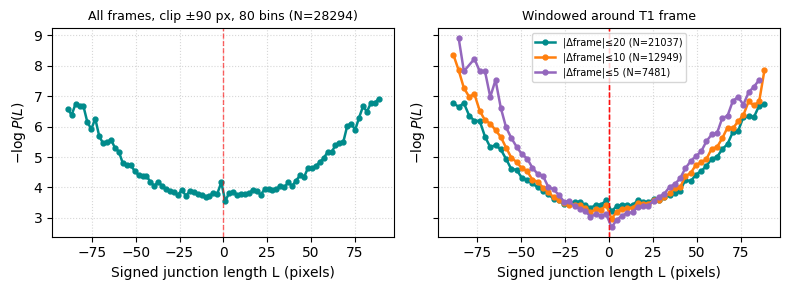

In [39]:
import matplotlib.pyplot as plt

def plot_neg_log_p(values: np.ndarray, *, clip: float | None = None,
                   nbins: int = 80, ax=None, label: str | None = None,
                   color='darkcyan'):
    v = values[np.isfinite(values)]
    if clip is not None:
        v = v[np.abs(v) <= clip]
    if v.size < 10:
        print(f'too few samples ({v.size})'); return
    lo = -clip if clip is not None else v.min()
    hi = +clip if clip is not None else v.max()
    edges_ = np.linspace(lo, hi, nbins + 1)
    counts, edges_ = np.histogram(v, bins=edges_)
    p_ = counts / v.size
    centers = 0.5 * (edges_[:-1] + edges_[1:])
    mask = p_ > 0
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.4, 2.8))
    ax.plot(centers[mask], -np.log(p_[mask]), '-o', lw=1.8, ms=3.5,
            color=color, label=label)
    ax.axvline(0, color='red', ls='--', lw=1, alpha=0.6)
    ax.set_xlabel('Signed junction length L (pixels)')
    ax.set_ylabel(r'$-\log P(L)$')
    ax.grid(True, ls=':', alpha=0.5)
    return ax

vals_all = signed_length_samples['signed_length'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
plot_neg_log_p(vals_all, clip=90, nbins=80, ax=axes[0])
axes[0].set_title(f'All frames, clip ±90 px, 80 bins (N={(np.abs(vals_all)<=90).sum()})', fontsize=9)

for W, color in [(20, 'darkcyan'), (10, 'tab:orange'), (5, 'tab:purple')]:
    sub = signed_length_samples[signed_length_samples['dframe'].abs() <= W]
    plot_neg_log_p(sub['signed_length'].to_numpy(), clip=90, nbins=60,
                   ax=axes[1], label=f'|Δframe|≤{W} (N={len(sub)})', color=color)
axes[1].set_title('Windowed around T1 frame', fontsize=9)
axes[1].legend(fontsize=7)
fig.tight_layout(); plt.show()


### Sanity check: unsigned junction-length distribution

Cell-cell interfaces are often fragmented in the segmentation — a single junction between a pair of cells can be split into multiple disconnected edge rows in the same frame. First we sum fragment lengths per `(position, frame, cell_pair)` to recover the true junction length, then pool across positions and plot $-\log P(L)$ for **all** junctions (no T1 filter, no sign convention).


86,235 raw fragments → 40,724 merged junctions; median=32.38, max=185.56


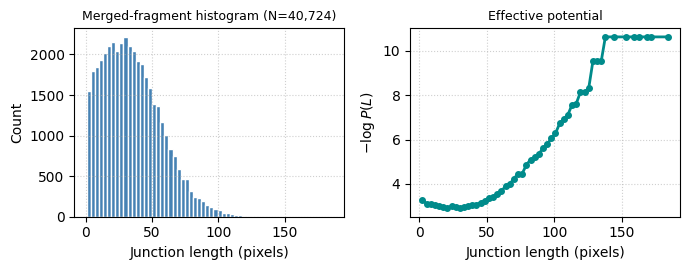

In [40]:
cc = edges[edges['kind'] == 'cell_cell'].copy()
cc['pair'] = list(zip(np.minimum(cc['cell_a'], cc['cell_b']), np.maximum(cc['cell_a'], cc['cell_b'])))
junction_lengths = (
    cc.groupby(['position', 'frame', 'pair'], as_index=False)['length'].sum()
      .rename(columns={'length': 'junction_length'})
)
all_lengths = junction_lengths['junction_length'].to_numpy()
all_lengths = all_lengths[np.isfinite(all_lengths) & (all_lengths > 0)]
print(f'{len(cc):,} raw fragments → {all_lengths.size:,} merged junctions; '
      f'median={np.median(all_lengths):.2f}, max={all_lengths.max():.2f}')

n = all_lengths.size
nbins = max(20, min(60, int(np.sqrt(n) * 0.85)))
bin_edges = np.linspace(all_lengths.min(), all_lengths.max(), nbins + 1)
counts, bin_edges = np.histogram(all_lengths, bins=bin_edges)
p_ = counts / n
centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
mask = p_ > 0

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8))
axes[0].hist(all_lengths, bins=bin_edges, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Junction length (pixels)'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Merged-fragment histogram (N={n:,})', fontsize=9)
axes[1].plot(centers[mask], -np.log(p_[mask]), '-o', color='darkcyan', lw=2, ms=4)
axes[1].set_xlabel('Junction length (pixels)'); axes[1].set_ylabel(r'$-\log P(L)$')
axes[1].set_title('Effective potential', fontsize=9)
for ax in axes: ax.grid(True, ls=':', alpha=0.6)
fig.tight_layout(); plt.show()


### Signed-length histogram (same recipe as the unsigned one)

Same binning logic as the merged-fragment cell above, but plotting the signed central-junction lengths from `signed_length_samples` (losing pair `+L`, gaining pair `−L`).


28,436 signed samples after clip ±100; |median|=25.68


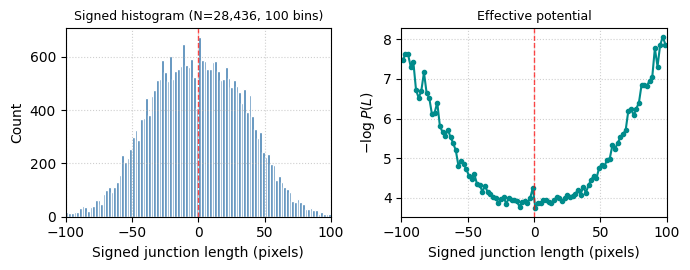

In [41]:
signed_vals = signed_length_samples['signed_length'].to_numpy()
signed_vals = signed_vals[np.isfinite(signed_vals)]
CLIP = 100.0
signed_vals = signed_vals[np.abs(signed_vals) <= CLIP]
n = signed_vals.size
print(f'{n:,} signed samples after clip ±{CLIP:.0f}; '
      f'|median|={np.median(np.abs(signed_vals)):.2f}')

nbins = 100  # ~2 px per bin over [-100, 100]
bin_edges = np.linspace(-CLIP, CLIP, nbins + 1)
counts, bin_edges = np.histogram(signed_vals, bins=bin_edges)
p_ = counts / n
centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
mask = p_ > 0

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8))
axes[0].hist(signed_vals, bins=bin_edges, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', ls='--', lw=1, alpha=0.7)
axes[0].set_xlabel('Signed junction length (pixels)'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Signed histogram (N={n:,}, {nbins} bins)', fontsize=9)
axes[1].plot(centers[mask], -np.log(p_[mask]), '-o', color='darkcyan', lw=1.5, ms=3)
axes[1].axvline(0, color='red', ls='--', lw=1, alpha=0.7)
axes[1].set_xlabel('Signed junction length (pixels)'); axes[1].set_ylabel(r'$-\log P(L)$')
axes[1].set_title('Effective potential', fontsize=9)
for ax in axes:
    ax.set_xlim(-CLIP, CLIP); ax.grid(True, ls=':', alpha=0.6)
fig.tight_layout(); plt.show()


### Signed histogram including non-T1 pairs

Include every merged cell-cell junction. Sign convention: pairs that ever appear as a *losing* pair in `t1_events/table` get `+L`; all other pairs (gaining pairs and pairs never involved in any T1) get `−L`. This treats the stable resting contact orientation as the negative well.


41,026 merged junctions; positive (losing-pair) = 10,528, negative (everything else) = 30,196


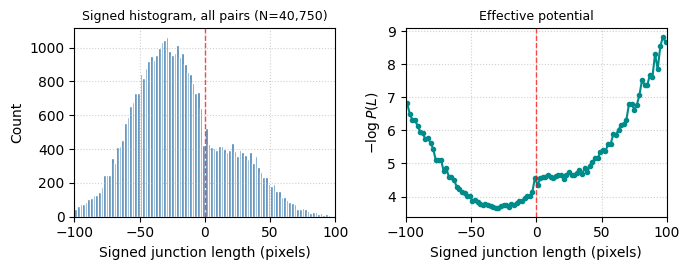

In [42]:
def signed_lengths_all_pairs(artifact: dict) -> pd.DataFrame:
    """Sign every merged junction in a position: losing-pair = +L, everything else = -L."""
    edges_a = artifact['edges']
    with h5py.File(artifact['path'], 'r') as h5:
        t1 = read_table(h5['t1_events/table'])

    cc = edges_a[edges_a['kind'] == 'cell_cell'].copy()
    if cc.empty:
        return pd.DataFrame(columns=['position','frame','pair','signed_length'])
    cc['pair'] = list(zip(np.minimum(cc['cell_a'], cc['cell_b']),
                          np.maximum(cc['cell_a'], cc['cell_b'])))
    merged = (
        cc.groupby(['frame', 'pair'], as_index=False)['length'].sum()
          .rename(columns={'length': 'junction_length'})
    )

    losing_pairs = set()
    if not t1.empty:
        for _, ev in t1.iterrows():
            losing_pairs.add(tuple(sorted((int(ev['losing_cell_a']), int(ev['losing_cell_b'])))))

    sign = np.where(merged['pair'].isin(losing_pairs), +1.0, -1.0)
    return pd.DataFrame({
        'position': artifact['position'],
        'frame': merged['frame'].astype(int),
        'pair': merged['pair'],
        'signed_length': sign * merged['junction_length'].to_numpy(),
    })

signed_length_samples_all = pd.concat(
    [signed_lengths_all_pairs(a) for a in artifacts],
    ignore_index=True,
)
n_pos = (signed_length_samples_all['signed_length'] > 0).sum()
n_neg = (signed_length_samples_all['signed_length'] < 0).sum()
print(f'{len(signed_length_samples_all):,} merged junctions; '
      f'positive (losing-pair) = {n_pos:,}, negative (everything else) = {n_neg:,}')

signed_vals = signed_length_samples_all['signed_length'].to_numpy()
signed_vals = signed_vals[np.isfinite(signed_vals)]
CLIP = 100.0
signed_vals = signed_vals[np.abs(signed_vals) <= CLIP]
n = signed_vals.size

nbins = 100
bin_edges = np.linspace(-CLIP, CLIP, nbins + 1)
counts, bin_edges = np.histogram(signed_vals, bins=bin_edges)
p_ = counts / n
centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
mask = p_ > 0

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8))
axes[0].hist(signed_vals, bins=bin_edges, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', ls='--', lw=1, alpha=0.7)
axes[0].set_xlabel('Signed junction length (pixels)'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Signed histogram, all pairs (N={n:,})', fontsize=9)
axes[1].plot(centers[mask], -np.log(p_[mask]), '-o', color='darkcyan', lw=1.5, ms=3)
axes[1].axvline(0, color='red', ls='--', lw=1, alpha=0.7)
axes[1].set_xlabel('Signed junction length (pixels)'); axes[1].set_ylabel(r'$-\log P(L)$')
axes[1].set_title('Effective potential', fontsize=9)
for ax in axes:
    ax.set_xlim(-CLIP, CLIP); ax.grid(True, ls=':', alpha=0.6)
fig.tight_layout(); plt.show()


Saved /home/aruppel/Projects/CellFlow/notebooks/effective_potential_signed.svg  (N=40,750)


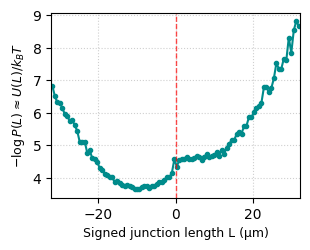

In [43]:
plt.rcParams['svg.fonttype'] = 'none'  # keep <text> elements editable in Inkscape
PX_TO_UM = 0.322
CLIP_UM = 100.0 * PX_TO_UM  # ≈ 32.2 µm
NBINS = 100

vals_um = signed_length_samples_all['signed_length'].to_numpy() * PX_TO_UM
vals_um = vals_um[np.isfinite(vals_um)]
vals_um = vals_um[np.abs(vals_um) <= CLIP_UM]
n = vals_um.size

bin_edges = np.linspace(-CLIP_UM, CLIP_UM, NBINS + 1)
counts, bin_edges = np.histogram(vals_um, bins=bin_edges)
p_ = counts / n
centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
mask = p_ > 0
neg_log_p = -np.log(p_[mask])

fig, ax = plt.subplots(figsize=(3.2, 2.6))
ax.plot(centers[mask], neg_log_p, '-o', color='darkcyan', lw=1.5, ms=3)
ax.axvline(0, color='red', ls='--', lw=1, alpha=0.7)
ax.set_xlabel('Signed junction length L (µm)', fontsize=9)
ax.set_ylabel(r'$-\log P(L) \approx U(L)/k_B T$', fontsize=9)
ax.set_xlim(-CLIP_UM, CLIP_UM)
ax.grid(True, ls=':', alpha=0.6)
fig.tight_layout()

svg_path = NOTEBOOK_DIR / 'effective_potential_signed.svg'
fig.savefig(svg_path)
print(f'Saved {svg_path.resolve()}  (N={n:,})')
plt.show()
